## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [ ]:
# Adicionar o conteúdo do drive no caminho do sistema

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!ls

In [ ]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [ ]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

### 1.1 Importar Libs

In [1]:
from pathlib import Path
import os
import sys

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from scikitplot.metrics import plot_ks_statistic
import autogluon.tabular
from autogluon.tabular import TabularDataset, TabularPredictor
from joblib import dump, load

from churn_preprocessing import load_split_datasets, OUTPUT_PREFIX, TARGET_COL
from ml_utils import (
    ks_test, predict_scores, compute_metrics, 
    train_model, evaluate_model,
    build_hyperparameter_space, print_hyperparameter_space,
    plot_confusion_matrix, plot_roc_curve,
    get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE)

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style('whitegrid')

print("Bibliotecas importadas com sucesso")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Autogluon: {autogluon.tabular.__version__}")
print(f"PyTorch: {torch.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())


c:\Programming\26.1\RN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas importadas com sucesso
Pandas: 2.3.3
NumPy: 2.3.5
Autogluon: 1.5.0
PyTorch: 2.6.0+cu124
Device: CUDA


In [2]:

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "datasets").exists() and (PROJECT_DIR / "projeto-churn").exists():
    PROJECT_DIR = PROJECT_DIR / "projeto-churn"

os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / "datasets"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
SEARCH_DIR = PROJECT_DIR / "searches"
PREDICTOR_PATH = MODELS_DIR / "mitra_autogluon"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(f"Projeto em: {PROJECT_DIR.resolve()}")
print(f"Dataset dir: {DATA_DIR.resolve()}")
print(f"Models dir: {MODELS_DIR.resolve()}")
print(f"Predictor path: {PREDICTOR_PATH.resolve()}")
print(f"Results dir: {RESULTS_DIR.resolve()}")

Projeto em: C:\Programming\26.1\RN\projetos-if702\projeto-churn
Dataset dir: C:\Programming\26.1\RN\projetos-if702\projeto-churn\datasets
Models dir: C:\Programming\26.1\RN\projetos-if702\projeto-churn\models
Predictor path: C:\Programming\26.1\RN\projetos-if702\projeto-churn\models\mitra_autogluon
Results dir: C:\Programming\26.1\RN\projetos-if702\projeto-churn\results


### 1.2 Configuração do Modelo

In [3]:


MODEL_NAME = 'Mitra'
MODEL_CLASS = TabularPredictor
module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)


Modelo configurado: Mitra
autogluon.tabular.predictor.predictor


## 2. Carregamento dos Dados

In [4]:
print('=== CARREGAMENTO DOS DATASETS PRÉ-PROCESSADOS ===')

train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)

train_ag = TabularDataset(train_data.copy())
val_ag = TabularDataset(val_data.copy())
test_ag = TabularDataset(test_data.copy())

print(f'Treino: {train_data.shape}')
print(f'Validação: {val_data.shape}')
print(f'Teste: {test_data.shape}')
print(f'Coluna alvo: {TARGET_COL}')
print(f'Features: {train_data.shape[1] - 1}')

print('\nDistribuição das classes:')
print('Treino:', train_data[TARGET_COL].value_counts().to_dict())
print('Validação:', val_data[TARGET_COL].value_counts().to_dict())
print('Teste:', test_data[TARGET_COL].value_counts().to_dict())

=== CARREGAMENTO DOS DATASETS PRÉ-PROCESSADOS ===
Treino: (5174, 20)
Validação: (2586, 20)
Teste: (1762, 20)
Coluna alvo: Churn
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Validação: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [5]:
print('Primeiras linhas do dataset de treino:')
train_data.head()



Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3 Configuração do predictor

In [6]:

EVAL_METRIC = 'roc_auc'
TIME_LIMIT_SECONDS = 3600
RANDOM_SEED = 42

In [9]:

print(f'AutoGluon predictor path: {PREDICTOR_PATH}')
print(f'Label: {TARGET_COL}')
print(f'Treino: {train_ag.shape}')
print(f'Validação: {val_ag.shape}')
print(f'Teste: {test_ag.shape}')
print(f'Métrica principal: {EVAL_METRIC}')

AutoGluon predictor path: c:\Programming\26.1\RN\projetos-if702\projeto-churn\models\mitra_autogluon
Label: Churn
Treino: (5174, 20)
Validação: (2586, 20)
Teste: (1762, 20)
Métrica principal: roc_auc


In [8]:
predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type='binary',
    eval_metric=EVAL_METRIC,
    path=str(PREDICTOR_PATH),
    verbosity=2,
)



In [10]:
hyperparameters = {
    'MITRA': {
        'fine_tune': False,
    }
}

### 3.2 Treinamento

In [ ]:
predictor = predictor.fit(
    train_data=train_ag,
    tuning_data=val_ag,
    hyperparameters=hyperparameters,
    time_limit=TIME_LIMIT_SECONDS,
    verbosity=2,
    ag_args_fit={'num_gpus': 1 if torch.cuda.is_available() else 0, 'ag.max_memory_usage_ratio': 8}
)

leaderboard_df = predictor.leaderboard(val_ag, silent=True)
display(leaderboard_df)
print(f'Predictor salvo em: {PREDICTOR_PATH}')

### 3.3 Avaliação preliminar

In [11]:
## Carregar o predictor salvo
predictor = TabularPredictor.load(str(PREDICTOR_PATH))
print(f'Predictor carregado de: {PREDICTOR_PATH}')

Predictor carregado de: c:\Programming\26.1\RN\projetos-if702\projeto-churn\models\mitra_autogluon


In [ ]:
val_metrics, val_preds, val_scores = evaluate_model(
    predictor,
    val_ag,
    val_data[TARGET_COL].to_numpy(),
    device=device,
)

test_metrics, test_preds, test_scores = evaluate_model(
    predictor,
    test_ag,
    test_data[TARGET_COL].to_numpy(),
    device=device,
)

train_metrics, train_preds, train_scores = evaluate_model(
    predictor,
    train_ag,
    train_data[TARGET_COL].to_numpy(),
    device=device,
)



In [13]:

print('\nMétricas de treino:')
print(train_metrics)
print('Métricas de validação:')
print(val_metrics)
print('\nMétricas de teste:')
print(test_metrics)


Métricas de treino:
{'accuracy': 0.7754155392346347, 'precision': 0.7534685165421559, 'recall': 0.818708929261693, 'f1': 0.784735087069285, 'auroc': 0.8633625592803004, 'ks_stat': 0.5539234634712021, 'confusion_matrix': {'tn': 1894, 'fp': 693, 'fn': 469, 'tp': 2118}, 'mse': 0.1496162555594038, 'cross_entropy': 0.4568536115002904}
Métricas de validação:
{'accuracy': 0.7548337200309359, 'precision': 0.7315530569219958, 'recall': 0.8051044083526682, 'f1': 0.7665684830633285, 'auroc': 0.8409910225145931, 'ks_stat': 0.5336426914153132, 'confusion_matrix': {'tn': 911, 'fp': 382, 'fn': 252, 'tp': 1041}, 'mse': 0.16389317377704102, 'cross_entropy': 0.49557618601029363}

Métricas de teste:
{'accuracy': 0.7468785471055619, 'precision': 0.5149456521739131, 'recall': 0.8098290598290598, 'f1': 0.6295681063122923, 'auroc': 0.8440947040251523, 'ks_stat': 0.545991360519954, 'confusion_matrix': {'tn': 937, 'fp': 357, 'fn': 89, 'tp': 379}, 'mse': 0.16468930823051703, 'cross_entropy': 0.4862818141506508

### 3.4 Métricas de validação e teste

In [17]:
metrics_df = pd.DataFrame([
    {'split': 'train', **train_metrics},
    {'split': 'val', **val_metrics},
    {'split': 'test', **test_metrics},
])

display(metrics_df[['split', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'ks_stat']])

,split,accuracy,precision,recall,f1,auroc,ks_stat
0,train,0.775416,0.753469,0.818709,0.784735,0.863363,0.553923
1,val,0.754834,0.731553,0.805104,0.766568,0.840991,0.533643
2,test,0.746879,0.514946,0.809829,0.629568,0.844095,0.545991


In [15]:
print(classification_report(test_data[TARGET_COL].to_numpy(), test_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1294
           1       0.51      0.81      0.63       468

    accuracy                           0.75      1762
   macro avg       0.71      0.77      0.72      1762
weighted avg       0.81      0.75      0.76      1762



KS Statistic: 0.5460


<Axes: title={'center': 'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

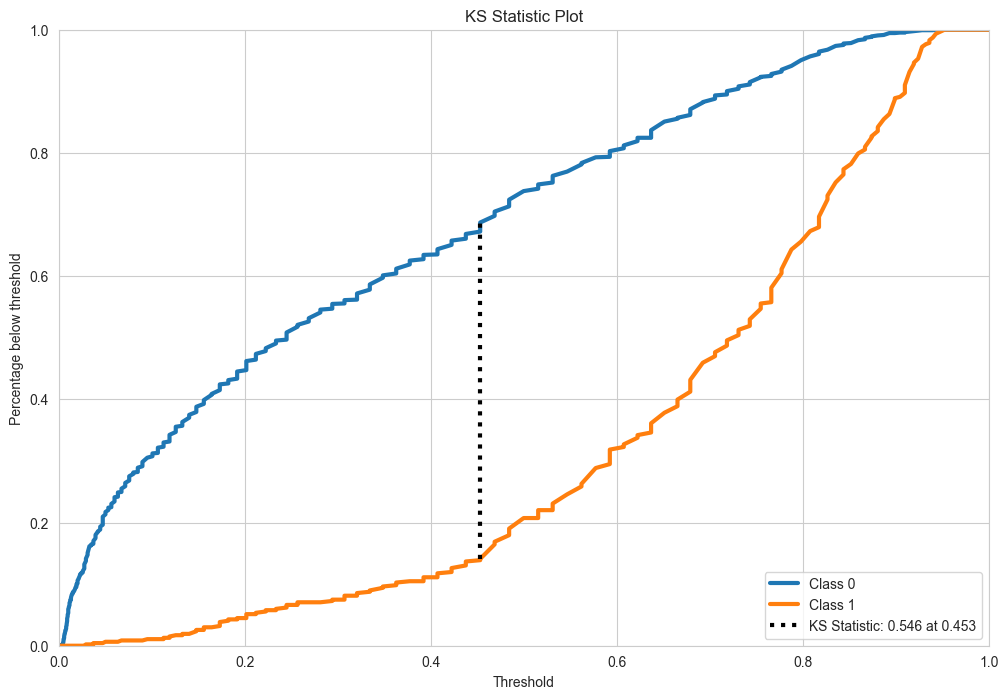

In [15]:
ks_result = ks_test(test_data[TARGET_COL].to_numpy(), test_scores)
print(f"KS Statistic: {ks_result['ks_stat']:.4f}")
plot_ks_statistic(
    test_data[TARGET_COL].to_numpy(),
    np.column_stack([1.0 - test_scores, test_scores]),
)

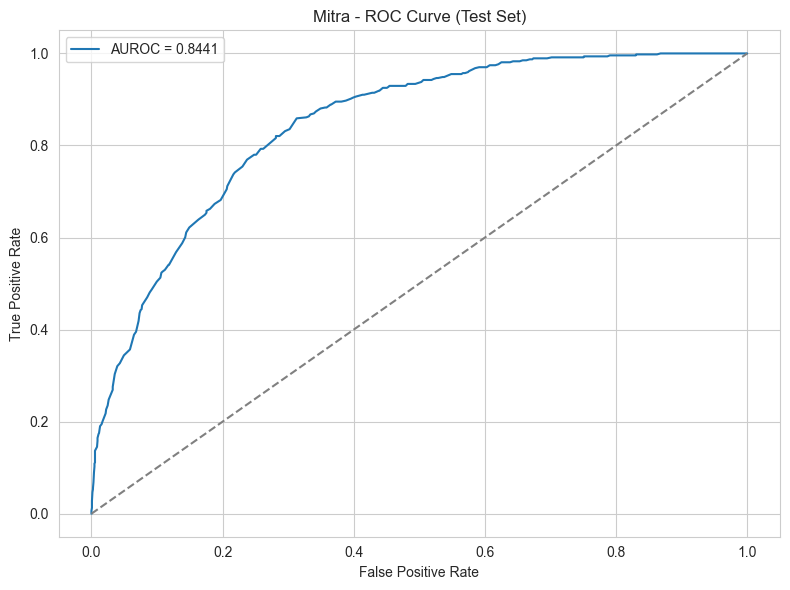

In [16]:
fig, ax = plot_roc_curve(
    test_data[TARGET_COL].to_numpy(),
    test_scores,
)
ax.set_title(f'{MODEL_NAME} - ROC Curve (Test Set)')
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / f'{MODEL_NAME.lower()}_roc_curve.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

In [17]:
print('Treinamento e avaliação do Mitra concluídos.')
print(f'Predictor em: {PREDICTOR_PATH}')
print(f'Label: {TARGET_COL}')

Treinamento e avaliação do Mitra concluídos.
Predictor em: c:\Programming\26.1\RN\projetos-if702\projeto-churn\models\mitra_autogluon
Label: Churn


## 4. Salvamento dos resultados

In [19]:
RESULTS_FOLDER = 'results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)



In [19]:
train_pred_df = pd.DataFrame({
    'y_true': train_data[TARGET_COL].to_numpy(),
    'y_pred': train_preds,
    'y_score': train_scores,
})

val_pred_df = pd.DataFrame({
    'y_true': val_data[TARGET_COL].to_numpy(),
    'y_pred': val_preds,
    'y_score': val_scores,
})

test_pred_df = pd.DataFrame({
    'y_true': test_data[TARGET_COL].to_numpy(),
    'y_pred': test_preds,
    'y_score': test_scores,
})

train_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_train_predictions.csv'), index=False)
val_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_val_predictions.csv'), index=False)
test_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_test_predictions.csv'), index=False)

print('Predições salvas em CSV.')

Predições salvas em CSV.


### 4.2 Matriz de confusão

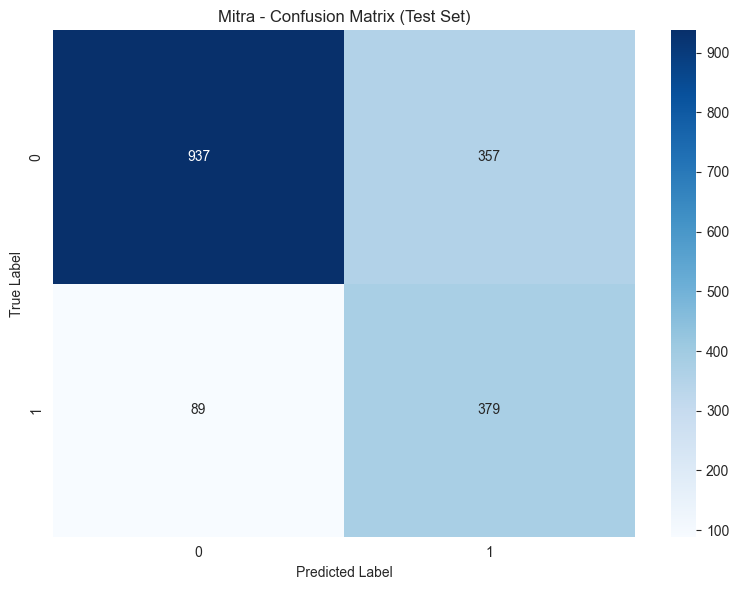

In [22]:
cm = confusion_matrix(test_data[TARGET_COL].to_numpy(), test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 4.3 Salvar resultados finais

In [20]:
final_results = {
    'model_name': MODEL_NAME,
    'predictor_path': PREDICTOR_PATH,
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'evaluation_metric': EVAL_METRIC,
    'time_limit_seconds': TIME_LIMIT_SECONDS,
}

final_path = os.path.join(RESULTS_FOLDER, f'{MODEL_NAME.lower()}_final_results.json')
with open(final_path, 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print(f'Resultados salvos em: {final_path}')

Resultados salvos em: results\mitra_final_results.json
